In [1]:
# Imports
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Defining plotting scale
cm = 1/2.54
font = 8
font_label = 10

# Defining color scheme
colors = ['darkblue',  'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

## Figure 2

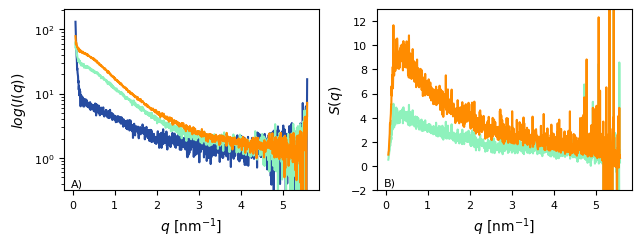

In [44]:
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/SAXS_data_Sep_2025_Grenoble/reviewed_data/Hst1_std/'
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)

def Intensity_plotting(path, Rg, I0, color, scaling_factor):
    q, I = np.genfromtxt(path, usecols=(0, 1), unpack=True, skip_header=3, skip_footer=9)
    q = q
    I = I
    ax[0].plot(q, I*scaling_factor, color=color_list[color])
    #ax[1].plot((q*Rg), (((q*Rg)**2)*(I/I0)), color=color_list[color])

Intensity_plotting((work_dir + '0p68_20frames.dat'), 1.70, 7.25, 15, 1.1)
Intensity_plotting((work_dir + '2p75_30frames.dat'), 1.80, 29.34, 55, 1.0)
Intensity_plotting((work_dir + '5p5_30frames.dat'), 1.93, 66.53, 99, 0.7)
q, S = np.genfromtxt((work_dir + 'S_q_2p75.dat'), usecols=(0, 1), unpack=True, skip_header=3, skip_footer=9)
ax[1].plot(q, S, color=color_list[55])
q, S = np.genfromtxt((work_dir + 'S_q_5p5.dat'), usecols=(0, 1), unpack=True, skip_header=3, skip_footer=9)
ax[1].plot(q, S, color=color_list[99])

ax[0].set_yscale('log')
ax[0].set_ylim(10**-0.5)
ax[1].set_ylim(-2, 13)
ax[0].set_xlabel('$q$ [nm$^{-1}$]', fontsize=font_label)
ax[0].set_ylabel('$log(I(q))$', fontsize=font_label)
ax[1].set_xlabel('$q$ [nm$^{-1}$]', fontsize=font_label)
ax[1].set_ylabel('$S(q)$', fontsize=font_label)
ax[0].text(-0.05,  0.355, 'A)', fontsize=font)
ax[1].text(-0.05,  -1.65, 'B)', fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure2.pdf', dpi=1000)

## Figure 3

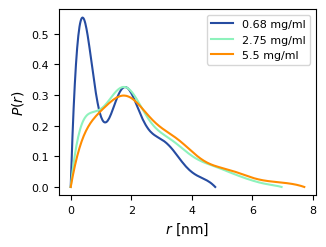

In [17]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (6*cm)), layout='constrained')
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/SAXS_data_Sep_2025_Grenoble/reviewed_data/Hst1_std/'
ax.tick_params(labelsize=font)

def PDDF_start_finder(path):
    with open(path) as PDDF:
        with open('/Users/oskarsvensson/Science/FILES/ARTICLES/Ref.out', 'r') as reference_file:
            lines = reference_file.readlines()
            ref = lines[160]
        lines = PDDF.readlines()
        counter = 0
        for line in lines:
            if line == ref:
                start_line = counter + 2
            counter += 1
    return start_line

def PDDF_plotting(path, start_line, color):
    r, P = np.genfromtxt(path, skip_header=start_line, unpack=True, usecols=(0, 1))
    step = r[1] - r[0]
    area = []
    for p in P:
        area.append(step*p)
    scaling_factor = 1/sum(area)
    P = P*scaling_factor
    ax.plot(r, P, color=color_list[color])

start_line = PDDF_start_finder(work_dir + '0p68_20frames.out')
PDDF_plotting((work_dir + '0p68_20frames.out'), start_line, 15)
start_line = PDDF_start_finder(work_dir + '2p75_30frames.out')
PDDF_plotting((work_dir + '2p75_30frames.out'), start_line, 55)
start_line = PDDF_start_finder(work_dir + '5p5_30frames.out')
PDDF_plotting((work_dir + '5p5_30frames.out'), start_line, 99)

ax.set_xlabel('$r$ [nm]', fontsize=font_label)
ax.set_ylabel('$P(r)$', fontsize=font_label)
ax.legend(['0.68 mg/ml', '2.75 mg/ml', '5.5 mg/ml'], fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure3.pdf', dpi=1000)

## Figure 4

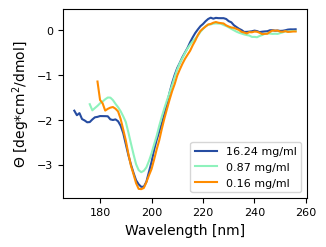

In [18]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (6*cm)), layout='constrained')
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/CD_Aarhus_Nov_2025/'

w, deg = np.genfromtxt((work_dir + 'Hst1_high.dat'), skip_header=24, usecols=(0, 1), unpack=True)
ax.plot(w, deg, color=color_list[15])
w, deg = np.genfromtxt((work_dir + 'Hst1_mid.dat'), skip_header=24, usecols=(0, 1), unpack=True)
ax.plot(w, deg, color=color_list[55])
w, deg = np.genfromtxt((work_dir + 'Hst1_low.dat'), skip_header=24, usecols=(0, 1), unpack=True)
ax.plot(w, deg, color=color_list[99])

ax.tick_params(labelsize=font)
ax.set_xlabel('Wavelength [nm]', fontsize=font_label)
ax.set_ylabel('$Θ$ [deg*cm$^{2}$/dmol]', fontsize=font_label)
ax.legend(['16.24 mg/ml', '0.87 mg/ml', '0.16 mg/ml'], fontsize=font, loc='lower right')
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure4.pdf', dpi=1000)

## Figure 5

In [3]:
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/'
sasa = np.genfromtxt((work_dir + 'sasa.xvg'), skip_header=24, usecols=(1), unpack=True)
decomp_data = np.zeros((len(sasa), 3))
decomp_data[:, 0] = sasa
decomp_data[:, 2] = range(1, (len(sasa) + 1))

counter = 0
pairdist_files = ['0.xvg', '1.xvg', '2.xvg', '3.xvg']
for file in pairdist_files: 
    pd = np.genfromtxt((work_dir + 'rg/' + file), skip_header=27, usecols=(1), unpack=True)
    if counter == 0:
        pd_ave = pd*10
    else:
        pd_ave += pd*10
    counter += 1
pd_ave = pd_ave/len(pairdist_files)
decomp_data[:, 1] = pd_ave
decomp_data = decomp_data.astype(int)

sasa_range = range(np.min(decomp_data[:, 0]), (np.max(decomp_data[:, 0]) + 1), 1)
pd_range = range(np.min(decomp_data[:, 1]), (np.max(decomp_data[:, 1]) + 1), 1)
print(sasa_range)
print(pd_range)

range(149, 226)
range(11, 22)


In [4]:
xx = np.expand_dims(np.arange(np.min(sasa_range), (np.max(sasa_range) + 2)), axis=0)
yy = np.expand_dims(np.arange(np.min(pd_range), (np.max(pd_range) + 2)), axis=1)
XX, YY = np.meshgrid(xx, yy)
DL = np.zeros((len(XX), len(XX[0])))
DL = DL.astype(int)
    
for frame in decomp_data:
    x_count = 0
    for x in XX[0]:
        if x == frame[0]:
            x_cord = x_count
        x_count += 1
    y_count = 0
    for y in YY:
        if y[0] == frame[1]:
            y_cord = y_count
        y_count += 1
    DL[y_cord, x_cord] += 1

In [5]:
sasa_count = np.zeros(len(sasa_range))
for frame in decomp_data[:, 0]:
    counter = 0
    for s in sasa_range:
        if frame == s:
            sasa_count[counter] += 1
        counter += 1
            
pd_count = np.zeros(len(pd_range))
for frame in decomp_data[:, 1]:
    counter = 0
    for r in pd_range:
        if frame == r:
            pd_count[counter] += 1
        counter += 1

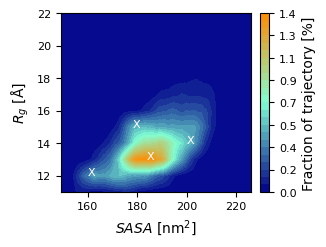

In [19]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (6*cm)), layout='constrained')
im = ax.contourf(XX, YY, ((DL/sum(sum(DL)))*100), cmap=cmap, levels=25)
cbar = fig.colorbar(im, location='right')
cbar.ax.tick_params(labelsize=font)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.set_label(label='Fraction of trajectory [%]', fontsize=font_label)
ax.tick_params(labelsize=font)
ax.set_xlabel('$SASA$ [nm$^{2}$]', fontsize=font_label)
ax.set_ylabel('$R_{g}$ [Å]', fontsize=font_label)
ax.text(160,  12, 'X', fontsize=font, color='white')
ax.text(178,  15, 'X', fontsize=font, color='white')
ax.text(184,  13, 'X', fontsize=font, color='white')
ax.text(200,  14, 'X', fontsize=font, color='white')
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure5.pdf', dpi=1000)

## Figure 6

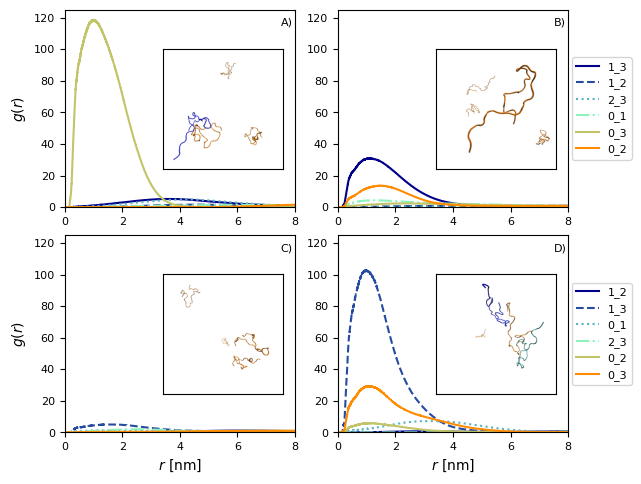

In [25]:
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/DL_decomp/H12/'
files = os.listdir(path)
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=((16*cm), (12*cm)), layout='constrained')

def file_func(path, axis1, axis2, colors, linestyles, pic_path):
    files = os.listdir(path)
    counter = 0
    for file in files:
        t, rdf = np.genfromtxt((path + file), usecols=(0, 1), unpack=True, skip_header=25)
        ax[axis1, axis2].plot(t, rdf, label=file[3:6], color=color_list[colors[counter]], linestyle=linestyles[counter])
        counter += 1
    axins = inset_axes(ax[axis1, axis2], width=1.3, height=1.2, loc='center right')
    axins.set_xticks([])
    axins.set_yticks([])
    img = np.asarray(Image.open(pic_path))
    axins.imshow(img)
    ax[axis1, axis2].set_ylim(0, 125)
    ax[axis1, axis2].set_xlim(0, 8)
    ax[axis1, axis2].tick_params(labelsize=font)

work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/DL_decomp/H12/'
pic_path = '/Users/oskarsvensson/Desktop/Current/Hst1_asso/12.png'
file_func(work_dir, 0, 0, [0, 15, 35, 55, 75, 99], ['-', '--', ':', '-.', '-', '-'], pic_path)
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/DL_decomp/H13/'
pic_path = '/Users/oskarsvensson/Desktop/Current/Hst1_asso/13.png'
file_func(work_dir, 0, 1, [0, 15, 35, 55, 75, 99], ['-', '--', ':', '-.', '-', '-'], pic_path)
ax[0, 1].legend(fontsize=font, loc='center right', bbox_to_anchor=(1.3, 0.5), ncols=1)
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/DL_decomp/H14/'
pic_path = '/Users/oskarsvensson/Desktop/Current/Hst1_asso/14.png'
file_func(work_dir, 1, 0, [0, 15, 35, 55, 75, 99], ['-', '--', ':', '-.', '-', '-'], pic_path)
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/DL_decomp/H15/'
pic_path = '/Users/oskarsvensson/Desktop/Current/Hst1_asso/15.png'
file_func(work_dir, 1, 1, [0, 15, 35, 55, 75, 99], ['-', '--', ':', '-.', '-', '-'], pic_path)
ax[1, 1].legend(fontsize=font, loc='center right', bbox_to_anchor=(1.3, 0.5), ncols=1)

ax[0, 0].set_ylabel('$g(r)$', fontsize=font_label)
ax[1, 0].set_ylabel('$g(r)$', fontsize=font_label)
ax[1, 0].set_xlabel('$r$ [nm]', fontsize=font_label)
ax[1, 1].set_xlabel('$r$ [nm]', fontsize=font_label)

ax[0, 0].text(7.5,  115, 'A)', fontsize=font)
ax[0, 1].text(7.5,  115, 'B)', fontsize=font)
ax[1, 0].text(7.5,  115, 'C)', fontsize=font)
ax[1, 1].text(7.5,  115, 'D)', fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure6.pdf', dpi=1000)

## Figure 8

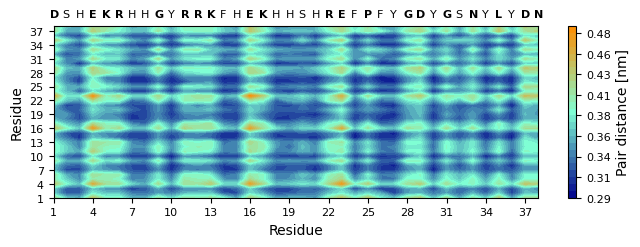

In [13]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_2_0.5mg/pairdist/'
Seq_x = np.expand_dims(np.arange(1, 39), axis=0) 
Seq_y = np.expand_dims(np.arange(1, 39), axis=1)
XX, YY = np.meshgrid(Seq_x, Seq_y)

length = range(0, 38)
for i in length:
    file = path + 'Res' + str(i) + '/out.dat'
    a, b = np.genfromtxt(file, unpack=True)
    if i == 0:
        Z = b
    elif i == 1:
        Z = np.append(arr=[Z], values=[b], axis=0)
    else:
        Z = np.append(arr=Z, values=[b], axis=0)
    
ticks = range(1, 39, 3)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
im = ax.contourf(XX, YY, Z, cmap=cmap, levels=25)
cbar = fig.colorbar(im, location='right')
cbar.ax.tick_params(labelsize=font)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
cbar.set_label(label='Pair distance [nm]', fontsize=font_label)
ax.set_xlabel('Residue', fontsize=font_label)
ax.set_ylabel('Residue', fontsize=font_label)

seq = 'DSHEKRHHGYRRKFHEKHHSHREFPFYGDYGSNYLYDN'
counter = 0.7
for letter in seq:
    if letter in 'DEKRPGNL':
        ax.text(counter,  40, letter, fontsize=font, fontweight='bold')
    else:
        ax.text(counter,  40, letter, fontsize=font)
    counter += 1
ax.tick_params(labelsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure8.pdf', dpi=1000)

In [ ]:
ax.set_title('$\mathbf{D}$' + 
             'SH' + 
             '$\mathbf{EK}$' + 
             '$\mathbf{R}$' +
             'HH' + 
             '$\mathbf{G}$' +
             'Y'
             '$\mathbf{RRK}$' + 
             'FH' +
             '$\mathbf{EK}$' +
             'HHSH' +
             '$\mathbf{RE}$' +
             'F' +
             '$\mathbf{P}$' +
             'FY' +
             '$\mathbf{GD}$' +
             'Y' +
             '$\mathbf{G}$' +
             'S' +
             '$\mathbf{N}$'  +
             'Y' +
             '$\mathbf{L}$' +
             'Y' +
             '$\mathbf{DN}$', fontsize=font_label, loc='left')

## Figure 9

In [51]:
def ave_func(path, nr_chains):
    counter = 0
    for chain in range(0, nr_chains, 1):
        a, b = np.genfromtxt((path + str(counter) + '.xvg'), usecols=(1, 2), unpack=True, skip_header=28)
        if counter == 0:
            a_ave = a
            b_ave = b
        else:
            a_ave += a
            b_ave += b
        counter += 1
    a_ave = np.array(a_ave/nr_chains)
    b_ave = np.array(b_ave/nr_chains)
    return a_ave, b_ave

def frame_func(Rg, Ree, SASA, RMS):
    frames = np.zeros((len(Rg), 4))
    frames[:, 0] = Ree
    frames[:, 1] = Rg
    frames[:, 2] = RMS
    frames[:, 3] = SASA
    scaler = StandardScaler()
    frames_scaled = scaler.fit_transform(frames)
    
    pca = PCA(n_components=2, random_state=44)
    pca_data = pca.fit_transform(frames_scaled)
    varience_ratio = pca.explained_variance_ratio_
    print(sum(varience_ratio))
    return pca_data

In [52]:
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_2_0.5mg/ML_decomp/'
Ree_2, Rg_2 = ave_func(path, 2)
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_2_0.5mg/sasa.xvg'
SASA_2 = np.genfromtxt(path, usecols=(1), unpack=True, skip_header=24)
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_2_0.5mg/rms.xvg'
RMS_2 = np.genfromtxt(path, usecols=(1), unpack=True, skip_header=18)
pca_2 = frame_func(Rg_2, Ree_2, SASA_2, RMS_2)

path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/ML_decomp/'
Ree_128, Rg_128 = ave_func(path, 2)
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/sasa.xvg'
SASA_128 = np.genfromtxt(path, usecols=(1), unpack=True, skip_header=24)
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/rms.xvg'
RMS_128 = np.genfromtxt(path, usecols=(1), unpack=True, skip_header=18)
pca_128 = frame_func(Rg_128, Ree_128, SASA_128, RMS_128)

0.7533977859993335
0.7458067034223207


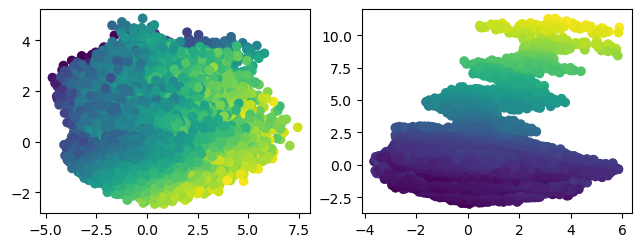

In [53]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
ax[0].scatter(pca_2[:, 0], pca_2[:, 1], c=SASA_2)
ax[1].scatter(pca_128[:, 0], pca_128[:, 1], c=SASA_128)

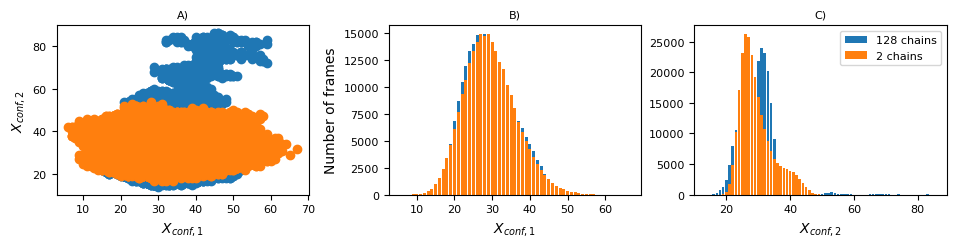

In [54]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=((24*cm), (6*cm)), layout='constrained')
def ML_decomp(data, alpha1, alpha2):
    frames = np.zeros((len(data), 3))
    frames[:, 0] = (data[:, 0] + 6)*alpha1
    frames[:, 1] = (data[:, 1] + 6)*alpha2
    frames[:, 2] = range(1, (len(data) + 1))
    frames = frames.astype(int)
    ax[0].scatter(frames[:, 0], frames[:, 1])

    pc1_range = range(np.min(frames[:, 0]), np.max(frames[:, 0]))
    count_1 = np.zeros((len(pc1_range)))
    counter = 0
    for a in pc1_range:
        for b in frames[:, 0]:
            if a == b:
                count_1[counter] += 1
        counter += 1
    ax[1].bar(pc1_range, count_1)

    pc2_range = range(np.min(frames[:, 1]), np.max(frames[:, 1]))
    count_2 = np.zeros((len(pc2_range)))
    counter = 0
    for a in pc2_range:
        for b in frames[:, 1]:
            if a == b:
                count_2[counter] += 1
        counter += 1
    ax[2].bar(pc2_range, count_2)
    return frames

frames_128 = ML_decomp(pca_128, 5, 5) 
frames_2 = ML_decomp(pca_2, 5, 5) 

ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)
ax[2].tick_params(labelsize=font)
ax[0].set_title('A)', fontsize=font)
ax[1].set_title('B)', fontsize=font)
ax[2].set_title('C)', fontsize=font)
ax[0].set_ylabel('$X_{conf, 2}$', fontsize=font_label)
ax[1].set_ylabel('Number of frames', fontsize=font_label)
ax[0].set_xlabel('$X_{conf, 1}$', fontsize=font_label)
ax[1].set_xlabel('$X_{conf, 1}$', fontsize=font_label)
ax[2].set_xlabel('$X_{conf, 2}$', fontsize=font_label)
ax[2].legend(['128 chains', '2 chains'], fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/SFigure4.png', dpi=1000)

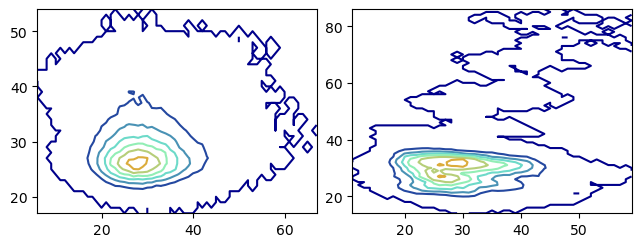

In [91]:
def FEL_func(frames):
    xx = np.expand_dims(np.arange(np.min(np.unique(frames[:, 0])), (np.max(np.unique(frames[:, 0])) + 1)), axis=0)
    yy = np.expand_dims(np.arange(np.min(np.unique(frames[:, 1])), (np.max(np.unique(frames[:, 1])) + 1)), axis=1)
    XX, YY = np.meshgrid(xx, yy)
    FEL = np.zeros((len(XX), len(XX[0])))
    FEL = FEL.astype(int)
    
    for frame in frames:
        x_count = 0
        for x in XX[0]:
            if x == frame[0]:
                x_cord = x_count
            x_count += 1
        y_count = 0
        for y in YY:
            if y[0] == frame[1]:
                y_cord = y_count
            y_count += 1
        FEL[y_cord, x_cord] += 1
    return XX, YY, FEL

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
XX_2, YY_2, FEL_2 = FEL_func(frames_2)
ax[0].contour(XX_2, YY_2, FEL_2, cmap=cmap)
XX_128, YY_128, FEL_128 = FEL_func(frames_128)
ax[1].contour(XX_128, YY_128, FEL_128, cmap=cmap)

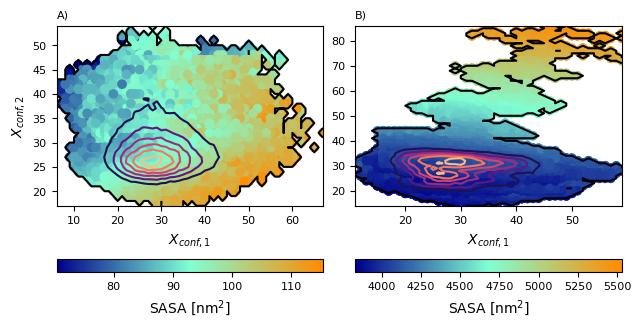

In [92]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (8*cm)), layout='constrained')

im = ax[0].scatter(frames_2[:, 0], frames_2[:, 1], c=SASA_2, cmap=cmap)
cbar = fig.colorbar(im, location='bottom')
cbar.ax.tick_params(labelsize=font)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.set_label(label='SASA [nm$^{2}$]', fontsize=font_label)
im = ax[0].contour(XX_2, YY_2, FEL_2, cmap='magma')

im = ax[1].scatter(frames_128[:, 0], frames_128[:, 1], c=SASA_128, cmap=cmap)
cbar = fig.colorbar(im, location='bottom')
cbar.ax.tick_params(labelsize=font)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.set_label(label='SASA [nm$^{2}$]', fontsize=font_label)
im = ax[1].contour(XX_128, YY_128, FEL_128, cmap='magma')

ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)
ax[0].set_ylabel('$X_{conf, 2}$', fontsize=font_label)
ax[0].set_xlabel('$X_{conf, 1}$', fontsize=font_label)
ax[1].set_xlabel('$X_{conf, 1}$', fontsize=font_label)
ax[0].set_title('A)', fontsize=font, color='black', loc='left')
ax[1].set_title('B)', fontsize=font, color='black', loc='left')
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure9.png', dpi=1000)

In [85]:
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/'
x = 18
y = 19
print(XX_128[y, x])
print(YY_128[y, x])
print(FEL_128[y, x])

selected_frames = []
for frame in frames_128:
    if (XX_128[y, x] == frame[0]) and (YY_128[y, x] == frame[1]):
        selected_frames.append(int(frame[2]))
print(selected_frames)

name = '2Decomp_2'
with open(work_dir + '/' + name + '.ndx', 'w') as file:
    file.write('[ {}_{} ]'.format(str(XX_128[y, x]), str(YY_128[y, x])) + '\n')
    counter = 0
    for frame in selected_frames:
        if counter == 6:
            file.write('    ' + str(frame) + '\n')
            counter = 0
        else:
            file.write('    ' + str(frame))
            counter += 1

29
33
1191
[7876, 7877, 7972, 7973, 7982, 7983, 7984, 8032, 8033, 8035, 8214, 8223, 8224, 8241, 8244, 9495, 9586, 9739, 9795, 9796, 9801, 9855, 9895, 9899, 9954, 9959, 9964, 9965, 9977, 9978, 10004, 10005, 10021, 10029, 10032, 10036, 10049, 10052, 10057, 10063, 10066, 10068, 10088, 10089, 10090, 10091, 10100, 10101, 10104, 10144, 10145, 10146, 10150, 10156, 10182, 10187, 10215, 10226, 10227, 10287, 19859, 20338, 20343, 20356, 20357, 20366, 20382, 20387, 20388, 20389, 20390, 20633, 20686, 20741, 22883, 22891, 23946, 24007, 24014, 24021, 24022, 24047, 24183, 24197, 24210, 24211, 24212, 24215, 24222, 24237, 24238, 24242, 24253, 24254, 24255, 24256, 24261, 24268, 24270, 24288, 24301, 24306, 24307, 24309, 24312, 24314, 24324, 24326, 24343, 24380, 24385, 24415, 24430, 24439, 24441, 24443, 24454, 24458, 24461, 24463, 24465, 24466, 24486, 24487, 24488, 24490, 24514, 24666, 24705, 24706, 24720, 24734, 24735, 24874, 24877, 24884, 24885, 24889, 24890, 24894, 24897, 24898, 24900, 24901, 24904, 249

## Figure 10

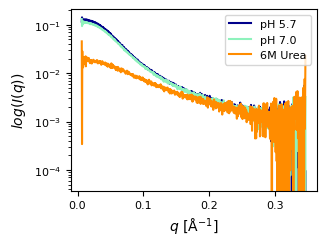

In [46]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (6*cm)), layout='constrained')
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/BioSAXS_Dec_2025/pH7.dat'
q, I = np.genfromtxt((path), skip_header=19, skip_footer=9, usecols=(0, 1), unpack=True)
ax.plot(q, I, color=color_list[0])
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/BioSAXS_Dec_2025/pH5.dat'
q, I = np.genfromtxt((path), skip_header=19, skip_footer=9, usecols=(0, 1), unpack=True)
ax.plot(q, I, color=color_list[55])
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/BioSAXS_Dec_2025/Urea.dat'
q, I = np.genfromtxt((path), skip_header=19, skip_footer=9, usecols=(0, 1), unpack=True)
ax.plot(q, I*1.5, color=color_list[99])
ax.set_yscale('log')

ax.tick_params(labelsize=font)
ax.set_xlabel('$q$ [Å$^{-1}$]', fontsize=font_label)
ax.set_ylabel('$log(I(q))$', fontsize=font_label)
ax.legend(['pH 5.7', 'pH 7.0', '6M Urea'], fontsize=font, loc='upper right')
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/Figure10.png', dpi=1000)

## Supp Figure 1

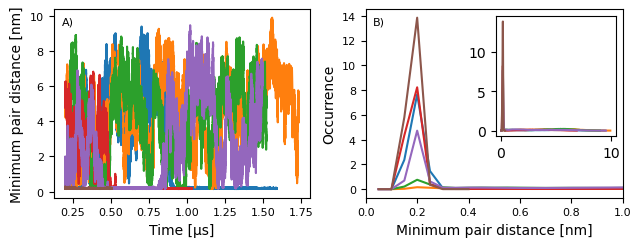

In [98]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
axins = inset_axes(ax[1], width=1.2, height=1.2, loc='upper right')
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/analysis/'
for number in range(1, 7, 1):
    t, d = np.genfromtxt((work_dir + 'conv_' + str(number) + '.xvg'), skip_header=24, usecols=(0, 1), unpack=True)
    ax[0].plot(t*(10**-6), d)
    bins, dist = np.genfromtxt((work_dir + 'conv_dist_' + str(number) + '.xvg'), skip_header=17, usecols=(0, 1), unpack=True)
    ax[1].plot(bins, dist)
    axins.plot(bins, dist)
ax[1].set_xlim(0, 1)
ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)
ax[0].set_xlabel('Time [\u03BCs]', fontsize=font_label)
ax[1].set_xlabel('Minimum pair distance [nm]', fontsize=font_label)
ax[0].set_ylabel('Minimum pair distance [nm]', fontsize=font_label)
ax[1].set_ylabel('Occurrence', fontsize=font_label)
ax[0].text(0.18,  9.5, 'A)', fontsize=font)
ax[1].text(0.027,  13.3, 'B)', fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/SFigure1.png', dpi=1000)

## Supp Figure 2

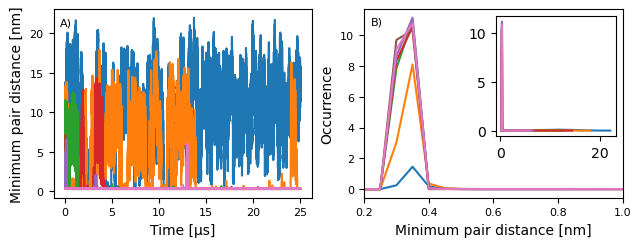

In [134]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
axins = inset_axes(ax[1], width=1.2, height=1.2, loc='upper right')
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/'
dirs = ['Hst1_2_0.5mg', 'Hst1_4_1mg', 'Hst1_8_2mg', 'Hst1_16_5mg', 'Hst1_32_10mg', 'Hst1_64_19mg', 'Hst1_128_38mg']
for entry in dirs:
    t, d = np.genfromtxt((work_dir + entry + '/conv.xvg'), skip_header=24, usecols=(0, 1), unpack=True)
    ax[0].plot(t*(10**-6), d)
    bins, dist = np.genfromtxt((work_dir + entry + '/conv_dist.xvg'), skip_header=17, usecols=(0, 1), unpack=True)
    ax[1].plot(bins, dist)
    axins.plot(bins, dist)
ax[1].set_xlim(0.2, 1)
ax[0].text(-0.5,  21, 'A)', fontsize=font)
ax[1].text(0.22,  10.65, 'B)', fontsize=font)
ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)
ax[0].set_xlabel('Time [\u03BCs]', fontsize=font_label)
ax[1].set_xlabel('Minimum pair distance [nm]', fontsize=font_label)
ax[0].set_ylabel('Minimum pair distance [nm]', fontsize=font_label)
ax[1].set_ylabel('Occurrence', fontsize=font_label)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/SFigure2.png', dpi=1000)

## Supp Figure 3

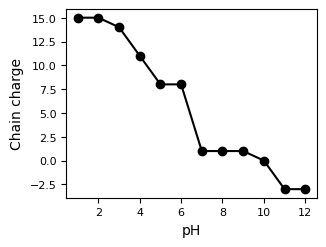

In [48]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (6*cm)), layout='constrained')
charges = [15, 15, 14, 11, 8, 8, 1, 1, 1, 0, -3, -3]
pHs = range(1, 13, 1)
ax.plot(pHs, charges, marker='o', color='black')
ax.tick_params(labelsize=font)
ax.set_xlabel('pH')
ax.set_ylabel('Chain charge')
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/SFigure3.png', dpi=1000)

## Supp Figure 5

Text(0.5, 0, '$X_{conf, 1}$')

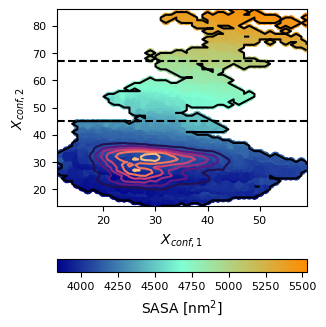

In [94]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((8*cm), (8*cm)), layout='constrained')
im = ax.scatter(frames_128[:, 0], frames_128[:, 1], c=SASA_128, cmap=cmap)
cbar = fig.colorbar(im, location='bottom')
cbar.ax.tick_params(labelsize=font)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.set_label(label='SASA [nm$^{2}$]', fontsize=font_label)
im = ax.contour(XX_128, YY_128, FEL_128, cmap='magma')
ax.axhline(67, color='black', linestyle='--')
ax.axhline(45, color='black', linestyle='--')
ax.tick_params(labelsize=font)
ax.set_ylabel('$X_{conf, 2}$', fontsize=font_label)
ax.set_xlabel('$X_{conf, 1}$', fontsize=font_label)

In [95]:
region_1 = []
region_2 = []
region_3 = []
for frame in frames_128:
    if frame[1] > 67:
        region_1.append(str(frame[2]))
    elif 67 >= frame[1] >= 45:
        region_2.append(str(frame[2]))
    elif frame[1] < 45:
        region_3.append(str(frame[2]))

In [96]:
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/oligmer_map/'
name = 'region_3'
with open(work_dir + '/' + name + '.ndx', 'w') as file:
    file.write('[ {} ]'.format(str(name )) + '\n')
    counter = 0
    for frame in region_3:
        if counter == 6:
            file.write('    ' + str(frame) + '\n')
            counter = 0
        else:
            file.write('    ' + str(frame))
            counter += 1
    file.write('\n')

In [55]:
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/oligmer_map/region_3/'
nr_polymer = range(0, 128, 1)
for p1 in nr_polymer:
    dist_min = []
    for p2 in nr_polymer:
        file = work_dir + 'Poly' + str(p1) + '/' + str(p1) + '_' + str(p2) + '.xvg'
        dist = np.genfromtxt(file, unpack=True, skip_header=24, usecols=(1))
        dist_min.append(np.min(dist))
    print('Polymer' + str(p1) + ': Finished')
    with open(work_dir + 'Poly' + str(p1) + '/out.dat', 'w') as save:
        for (n, d) in zip(nr_polymer, dist_min):
            save.write(str(n) + ' ' + str(d) + ' ' + '\n')

Polymer0: Finished
Polymer1: Finished
Polymer2: Finished
Polymer3: Finished
Polymer4: Finished
Polymer5: Finished
Polymer6: Finished
Polymer7: Finished
Polymer8: Finished
Polymer9: Finished
Polymer10: Finished
Polymer11: Finished
Polymer12: Finished
Polymer13: Finished
Polymer14: Finished
Polymer15: Finished
Polymer16: Finished
Polymer17: Finished
Polymer18: Finished
Polymer19: Finished
Polymer20: Finished
Polymer21: Finished
Polymer22: Finished
Polymer23: Finished
Polymer24: Finished
Polymer25: Finished
Polymer26: Finished
Polymer27: Finished
Polymer28: Finished
Polymer29: Finished
Polymer30: Finished
Polymer31: Finished
Polymer32: Finished
Polymer33: Finished
Polymer34: Finished
Polymer35: Finished
Polymer36: Finished
Polymer37: Finished
Polymer38: Finished
Polymer39: Finished
Polymer40: Finished
Polymer41: Finished
Polymer42: Finished
Polymer43: Finished
Polymer44: Finished
Polymer45: Finished
Polymer46: Finished
Polymer47: Finished
Polymer48: Finished
Polymer49: Finished
Polymer50:

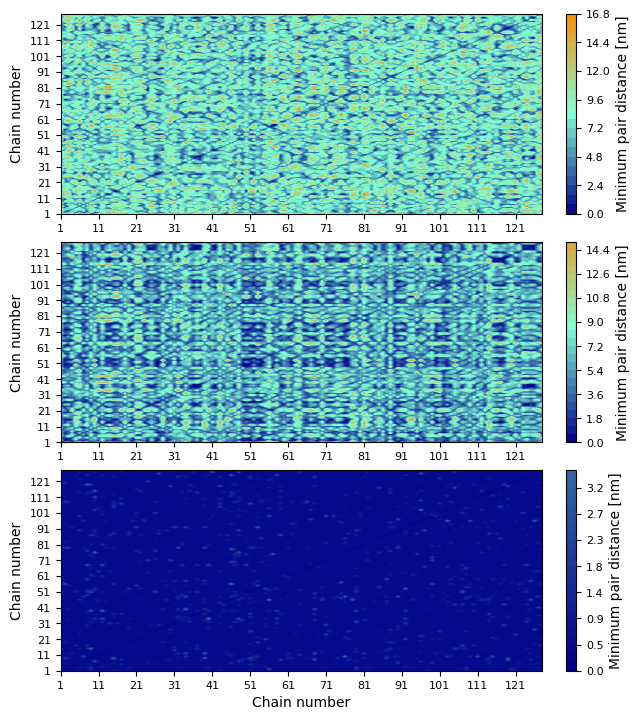

In [76]:
def plot_func(path, axis):
    Poly_x = np.expand_dims(np.arange(1, 129), axis=0) 
    Poly_y = np.expand_dims(np.arange(1, 129), axis=1)
    XX, YY = np.meshgrid(Poly_x, Poly_y)
    
    length = range(0, 128)
    for i in length:
        file = path + 'Poly' + str(i) + '/out.dat'
        a, b = np.genfromtxt(file, unpack=True)
        if i == 0:
            Z = b
        elif i == 1:
            Z = np.append(arr=[Z], values=[b], axis=0)
        else:
            Z = np.append(arr=Z, values=[b], axis=0)
            
    im = ax[axis].contourf(XX, YY, Z, cmap=cmap, levels=25, vmin=0, vmax=17)
    cbar = fig.colorbar(im, location='right')
    cbar.ax.tick_params(labelsize=font)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    cbar.set_label(label='Minimum pair distance [nm]', fontsize=font_label)
    ticks = range(1, 128, 10)
    ax[axis].set_xticks(ticks)
    ax[axis].set_yticks(ticks)
    ax[axis].tick_params(labelsize=font)

fig, ax = plt.subplots(ncols=1, nrows=3, figsize=((16*cm), (18*cm)), layout='constrained')
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/oligmer_map/region_1/'
plot_func(path, 0)
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/oligmer_map/region_2/'
plot_func(path, 1)
path = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/LLPS/analysis/Hst1_128_38mg/oligmer_map/region_3/'
plot_func(path, 2)

ax[2].set_xlabel('Chain number', fontsize=font_label)
ax[0].set_ylabel('Chain number', fontsize=font_label)
ax[1].set_ylabel('Chain number', fontsize=font_label)
ax[2].set_ylabel('Chain number', fontsize=font_label)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_figures/SFigure5.png', dpi=1000)